In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_csv("data/Extended_Employee_Performance_and_Productivity_Data.csv")


In [ ]:
df.shape


(100000, 20)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  

In [ ]:
# ==============================
# STEP 4: Import Libraries
# ==============================

# 1️⃣ Data Handling
import pandas as pd      # For working with tables (DataFrames)
import numpy as np       # For numerical operations and arrays

# 2️⃣ Data Visualization
import matplotlib.pyplot as plt  # For plotting charts and graphs

# 3️⃣ Machine Learning Utilities
from sklearn.model_selection import train_test_split, GridSearchCV
# train_test_split → split dataset into training and testing sets
# GridSearchCV → automatically find the best hyperparameters

from sklearn.preprocessing import StandardScaler
# StandardScaler → scales features to mean=0, std=1

# 4️⃣ Machine Learning Models
from sklearn.linear_model import LogisticRegression  # Logistic Regression
from sklearn.neighbors import KNeighborsClassifier   # K-Nearest Neighbors
from sklearn.svm import SVC                           # Support Vector Classifier

# 5️⃣ Model Evaluation
from sklearn.metrics import accuracy_score
# accuracy_score → to check how accurate your model is

# 6️⃣ Save / Load Models
import joblib
# joblib → save your trained model and scaler for later use


In [ ]:
df = pd.read_csv("data/Extended_Employee_Performance_and_Productivity_Data.csv")

In [ ]:
# Drop columns that are not needed for prediction
df.drop([
    'Employee_ID',        # Unique ID, not useful for model
    'Hire_Date',          # Already have Years_At_Company
    'Work_Hours_Per_Week',# Can be ignored for this model
    'Remote_Work_Frequency', # Irrelevant for performance prediction
    'Team_Size',          # Not used for this project
    'Resigned'            # Target is performance, not resignation
], axis=1, inplace=True)

# Check for missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())


Missing Values in Each Column:
Department                     0
Gender                         0
Age                            0
Job_Title                      0
Years_At_Company               0
Education_Level                0
Performance_Score              0
Monthly_Salary                 0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Training_Hours                 0
Promotions                     0
Employee_Satisfaction_Score    0
dtype: int64

Number of duplicate rows: 0


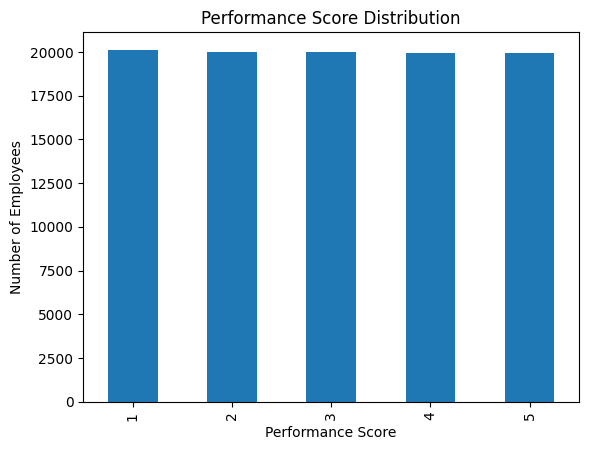

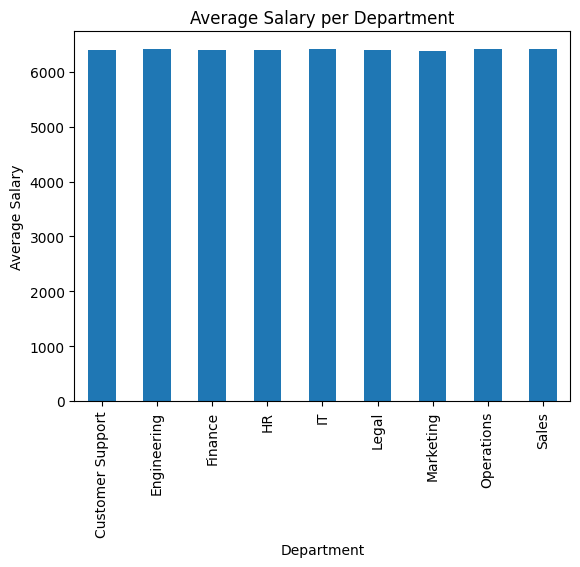

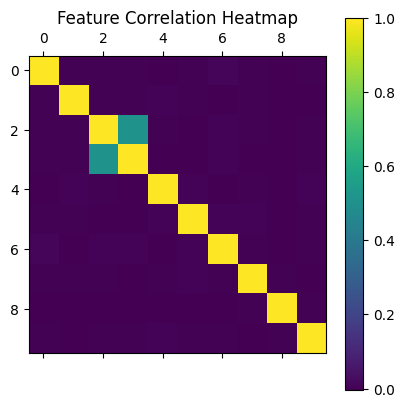

In [ ]:
import matplotlib.pyplot as plt

# 1️⃣ Performance Score Distribution
df['Performance_Score'].value_counts().plot(kind='bar')
plt.title("Performance Score Distribution")
plt.xlabel("Performance Score")
plt.ylabel("Number of Employees")
plt.show()

# 2️⃣ Department vs Average Salary
df.groupby('Department')['Monthly_Salary'].mean().plot(kind='bar')
plt.title("Average Salary per Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.show()

# 3️⃣ Correlation Heatmap (Only numeric columns)
numeric_cols = df.select_dtypes(include='number')  # Select only numeric columns
plt.matshow(numeric_cols.corr())
plt.colorbar()
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
# -----------------------------
# STEP 8: Feature Selection
# -----------------------------

# Features (X) – columns that help predict performance
X = df[[
    'Years_At_Company',           # How long the employee has worked
    'Monthly_Salary',             # Salary of the employee
    'Overtime_Hours',             # Extra hours worked
    'Projects_Handled',           # Number of projects handled
    'Promotions',                 # Number of promotions
    'Employee_Satisfaction_Score' # Satisfaction score between 0 and 1
]]

# Target (y) – what we want to predict
y = df['Performance_Score']       # Employee performance score

# Quick check
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)


Features (X) shape: (100000, 6)
Target (y) shape: (100000,)


In [ ]:
# -----------------------------
# STEP 9: Train-Test Split
# -----------------------------

from sklearn.model_selection import train_test_split

# Split the data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,            # Features and target
    test_size=0.2,   # 20% data for testing
    random_state=42  # For reproducibility
)

# Check shapes of the splits
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (80000, 6)
X_test shape: (20000, 6)
y_train shape: (80000,)
y_test shape: (20000,)


In [ ]:
# -----------------------------
# STEP 10: Feature Scaling
# -----------------------------
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling done!")


Feature scaling done!


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create logistic regression model
lr = LogisticRegression(max_iter=1000)

# Train the model
lr.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_lr = lr.predict(X_test_scaled)

# Check accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.3125


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Define KNN model
knn = KNeighborsClassifier()

# Hyperparameter grid
knn_params = {'n_neighbors': [3, 5, 7, 9]}

# GridSearchCV for hyperparameter tuning
grid_knn = GridSearchCV(knn, knn_params, cv=5)
grid_knn.fit(X_train_scaled, y_train)

# Best KNN model
best_knn = grid_knn.best_estimator_

# Predict and check accuracy
y_pred_knn = best_knn.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Accuracy: 0.3762


In [24]:
# -----------------------------
# STEP 13: Train SVC (Fast Version)
# -----------------------------
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Create SVC model with default parameters
# Using linear kernel (fast)
svc = SVC(kernel='linear', C=1, gamma='scale')

# Train the model
svc.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_svc = svc.predict(X_test_scaled)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred_svc)
print("SVC Accuracy:", accuracy)


SVC Accuracy: 0.2981


In [25]:
# -----------------------------
# STEP 14: Save Model and Scaler
# -----------------------------
import joblib

# Save trained LinearSVC model
joblib.dump(svc, "model/linear_svc_model.pkl")

# Save the StandardScaler used for scaling features
joblib.dump(scaler, "model/scaler.pkl")

print("Model and scaler saved successfully!")


Model and scaler saved successfully!


In [2]:
import joblib
import numpy as np

# Load saved model and scaler
scaler = joblib.load("model/scaler.pkl")
svc = joblib.load("model/linear_svc_model.pkl")

# Test on sample input
sample_input = np.array([[5, 5000, 10, 2, 1, 0.5]])  # Example employee
sample_scaled = scaler.transform(sample_input)
prediction = svc.predict(sample_scaled)
print("Sample Prediction:", prediction[0])


Sample Prediction: 1


c:\Users\Ruthu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
# -----------------------------
# STEP 17: Test ML Model and Predictions
# -----------------------------

import joblib
import numpy as np
from sklearn.metrics import accuracy_score

# 1️⃣ Load saved scaler and model
scaler = joblib.load("model/scaler.pkl")
svc = joblib.load("model/linear_svc_model.pkl")

# 2️⃣ Test on a single sample input
# Features: Years, Salary, Overtime, Projects, Promotions, Satisfaction
sample_input = np.array([[5, 5000, 10, 2, 1, 0.5]])
sample_scaled = scaler.transform(sample_input)
prediction = svc.predict(sample_scaled)
print("Sample Employee Prediction:", prediction[0])

# 3️⃣ Test on the test dataset (if you still have X_test and y_test)
try:
    X_test_scaled = joblib.load("model/X_test_scaled.pkl")
    y_test = joblib.load("model/y_test.pkl")
    
    y_test_pred = svc.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_test_pred)
    print("Test Set Accuracy:", accuracy)
except:
    print("X_test_scaled or y_test not found. Skip test dataset evaluation.")

# 4️⃣ Test multiple random inputs
random_inputs = np.array([
    [0, 1000, 0, 0, 0, 0.0],   # Worst case employee
    [40, 20000, 50, 10, 5, 1.0] # Best case employee
])
random_scaled = scaler.transform(random_inputs)
random_predictions = svc.predict(random_scaled)

print("Random Test Predictions:", random_predictions)


Sample Employee Prediction: 1
X_test_scaled or y_test not found. Skip test dataset evaluation.
Random Test Predictions: [1 5]


c:\Users\Ruthu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Ruthu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
df.describe()

,Employee_ID,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,41.029410,4.476070,2.995430,6403.211000,44.956950,24.431170,14.514930,7.008550,50.090500,10.013560,49.506060,0.999720,2.999088
std,28867.657797,11.244121,2.869336,1.414726,1372.508717,8.942003,14.469584,8.664026,4.331591,35.351157,5.495405,28.890383,0.815872,1.150719
min,1.000000,22.000000,0.000000,1.000000,3850.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,25000.750000,31.000000,2.000000,2.000000,5250.000000,37.000000,12.000000,7.000000,3.000000,25.000000,5.000000,25.000000,0.000000,2.010000
50%,50000.500000,41.000000,4.000000,3.000000,6500.000000,45.000000,24.000000,15.000000,7.000000,50.000000,10.000000,49.000000,1.000000,3.000000
75%,75000.250000,51.000000,7.000000,4.000000,7500.000000,53.000000,37.000000,22.000000,11.000000,75.000000,15.000000,75.000000,2.000000,3.990000
max,100000.000000,60.000000,10.000000,5.000000,9000.000000,60.000000,49.000000,29.000000,14.000000,100.000000,19.000000,99.000000,2.000000,5.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  

In [ ]:
df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [ ]:
df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False
